<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/04-Pandas/02_Olympics_History_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Reading & cleaning Data

In [2]:
bio_D=pd.read_csv('/content/drive/MyDrive/bios.csv')
bio_D.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


In [3]:
result_D=pd.read_parquet('/content/drive/MyDrive/results.parquet')
result_D.head()

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1912.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,17.0,True,None
1,1912.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jean Montariol,NaN,False,None
2,1920.0,Summer,Tennis,"Singles, Men (Olympic)",Jean-François Blanchy,1,FRA,None,32.0,True,None
3,1920.0,Summer,Tennis,"Doubles, Mixed (Olympic)",Jean-François Blanchy,1,FRA,Jeanne Vaussard,8.0,True,None
4,1920.0,Summer,Tennis,"Doubles, Men (Olympic)",Jean-François Blanchy,1,FRA,Jacques Brugnon,4.0,False,None


In [4]:
t_d=bio_D.merge(result_D,how='outer')
t_d.sample(4)

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,year,type,discipline,event,as,noc,team,place,tied,medal
192701,90346,Frank Høj,1973-01-04,NaN,NaN,NaN,Denmark,186.0,80.0,NaN,2004.0,Summer,Cycling Road (Cycling),"Road Race, Individual, Men (Olympic)",Frank Høj,DEN,None,8.0,False,None
63920,30304,Alfred Schwarzmann,1912-03-23,Fürth,Bayern,GER,Germany,NaN,NaN,2000-03-11,1952.0,Summer,Artistic Gymnastics (Gymnastics),"Horse Vault, Men (Olympic)",Alfred Schwarzmann,GER,None,13.0,True,None
53392,28517,Renate Schneider,1939-05-03,Berlin,Berlin,GER,Germany,159.0,50.0,NaN,1960.0,Summer,Artistic Gymnastics (Gymnastics),"Balance Beam, Women (Olympic)",Renate Schneider,GER,None,57.0,True,None
267569,125050,Sergio Llull,1987-11-15,NaN,NaN,NaN,Spain,192.0,91.0,NaN,2020.0,Summer,Basketball (Basketball),"Basketball, Men (Olympic)",Sergio Llull,ESP,Spain,6.0,False,None


In [5]:
t_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308646 entries, 0 to 308645
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   athlete_id    308646 non-null  int64  
 1   name          308646 non-null  object 
 2   born_date     305928 non-null  object 
 3   born_city     247091 non-null  object 
 4   born_region   247091 non-null  object 
 5   born_country  247091 non-null  object 
 6   NOC           308645 non-null  object 
 7   height_cm     236927 non-null  float64
 8   weight_kg     227305 non-null  float64
 9   died_date     73526 non-null   object 
 10  year          305807 non-null  float64
 11  type          305807 non-null  object 
 12  discipline    308407 non-null  object 
 13  event         308408 non-null  object 
 14  as            308408 non-null  object 
 15  noc           308407 non-null  object 
 16  team          121714 non-null  object 
 17  place         283193 non-null  float64
 18  tied

In [6]:
t_d.describe()

,athlete_id,height_cm,weight_kg,year,place
count,308646.000000,236927.000000,227305.000000,305807.000000,283193.000000
mean,72682.064164,175.350306,70.555223,1982.239223,16.102764
std,41324.080740,10.450772,14.163493,30.983982,19.322611
min,1.000000,127.000000,25.000000,1896.000000,1.000000
25%,34456.250000,168.000000,60.000000,1964.000000,5.000000
50%,73796.500000,175.000000,70.000000,1992.000000,9.000000
75%,107196.000000,183.000000,79.000000,2008.000000,20.000000
max,149814.000000,226.000000,198.000000,2022.000000,185.000000


### Country Ranking on Medal

In [7]:
medal_table = t_d.groupby(['NOC', 'medal']).size().unstack(fill_value=0)
medal_table = medal_table[['Gold', 'Silver', 'Bronze']].sort_values('Gold', ascending=False)
#This count each gold a person win even if they are in a team

In [8]:
gold_medal=t_d[t_d['medal']=='Gold']
gold_medal.groupby(gold_medal['NOC'])['medal'].count().sort_values(ascending=False)
#This count each gold a person win even if they are in a team

,medal
NOC,
United States,2709
Soviet Union,952
Great Britain,713
Germany,704
Italy,604
...,...
Suriname,1
Soviet Union Sweden Unified Team,1
Tajikistan,1


In [9]:

rename_dict = {
    'Soviet Union': 'Russian Federation',
    'East Germany': 'Germany'
}

t_d['NOC'] = t_d['NOC'].replace(rename_dict)

rmeadal_table=t_d[t_d['medal'].isin(['Gold','Silver','Bronze'])].drop_duplicates(subset=['year','event','NOC'])

medal_table=rmeadal_table.groupby(['NOC','medal']).size().unstack(fill_value=0)

medal_table=medal_table[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False)

medal_table.head(10)

medal,Gold,Silver,Bronze
NOC,,,
United States,901,692,626
Russian Federation,507,397,398
Germany,406,410,404
Great Britain,261,296,291
People's Republic of China,256,194,162
Italy,246,224,260
France,244,264,320
Sweden,185,197,228
Norway,184,151,153


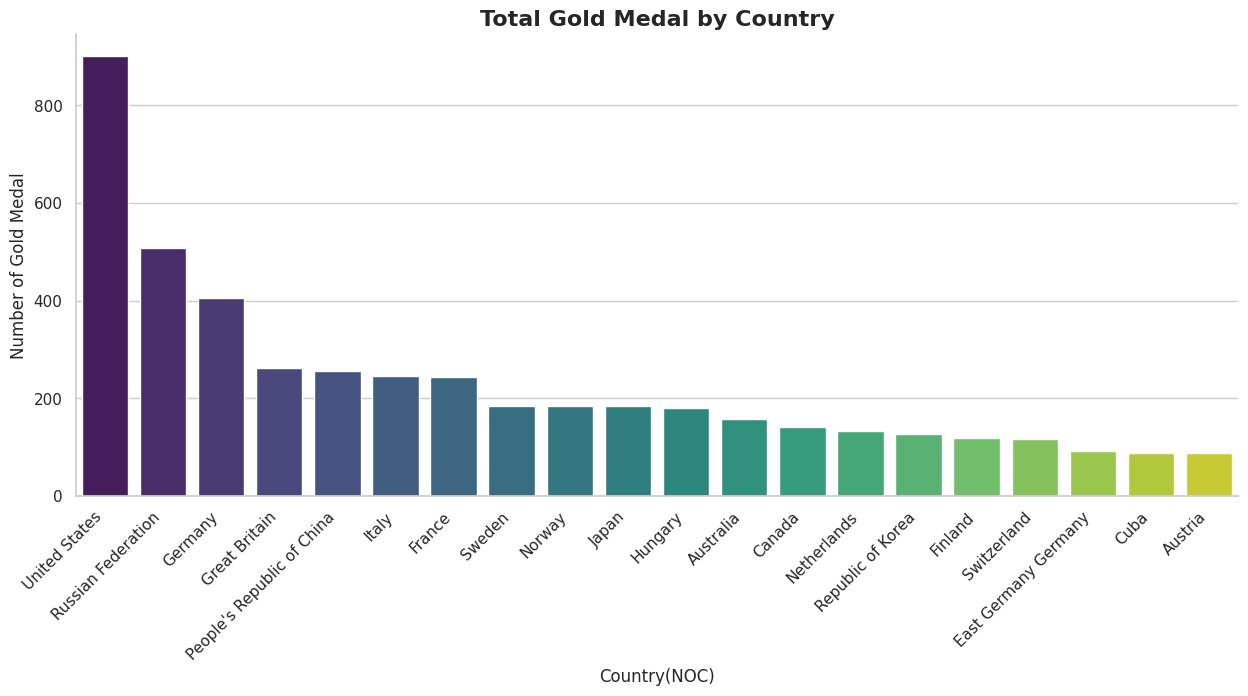

In [10]:
top_20=medal_table.head(20)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(15,6))


plt.title("Total Gold Medal by Country",fontsize=16, fontweight='bold')

sns.barplot(
            x=top_20.index,
            y=top_20['Gold'],
            hue=top_20.index,
            palette="viridis",
            legend=False
           )

plt.xticks(rotation=45,ha='right')#ha aligns the text better


plt.ylabel("Number of Gold Medal",fontsize=12)
plt.xlabel("Country(NOC)",fontsize=12)

sns.despine()

plt.show()

### Unique Participant from different region of INDIA

In [11]:
t_d.query('born_country=="IND" and born_region=="Uttar Pradesh" ')
it_d=t_d.query('NOC=="India" and born_country=="IND"')
unique_par=it_d.drop_duplicates(subset=['athlete_id'])

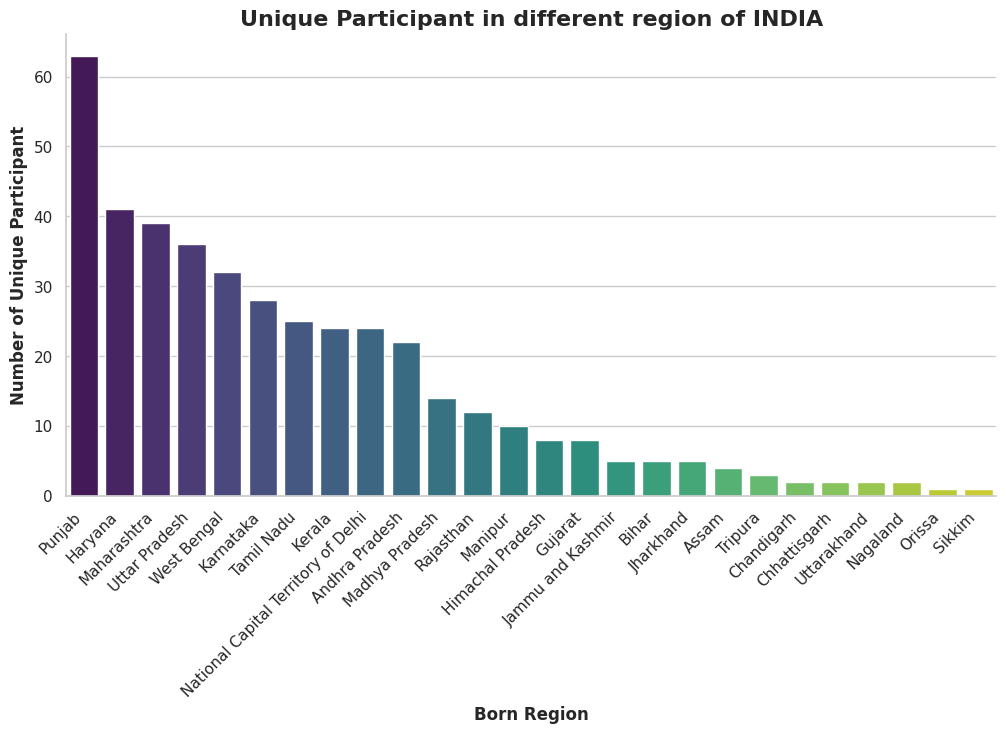

In [12]:
participant_d=unique_par.groupby(['born_region'])['name'].count().sort_values(ascending=False).reset_index()

#Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))

sns.barplot(
            x=participant_d['born_region'] ,
            y=participant_d['name'] ,
            hue=participant_d['born_region'],
            palette="viridis" ,
            legend=False
           )

plt.title("Unique Participant in different region of INDIA",fontsize=16,fontweight="bold")
plt.xlabel("Born Region",fontsize=12,fontweight="bold")
plt.ylabel("Number of Unique Participant",fontsize=12,fontweight="bold")

plt.xticks(rotation=45,ha="right")
sns.despine()

plt.show()


### Women Unique Participant

In [13]:
p_t_d=t_d[t_d['event'].str.contains('Women',na=False)& (t_d['type'] == 'Summer')]

u_p_d=p_t_d.drop_duplicates(subset=['athlete_id'])

unique_W_par=u_p_d.groupby(['year'])['name'].count().reset_index()

unique_W_par.head(10)

,year,name
0,1900.0,16
1,1904.0,6
2,1908.0,41
3,1912.0,53
4,1920.0,69
5,1924.0,108
6,1928.0,245
7,1932.0,97
8,1936.0,283
9,1948.0,376


##### Visuals

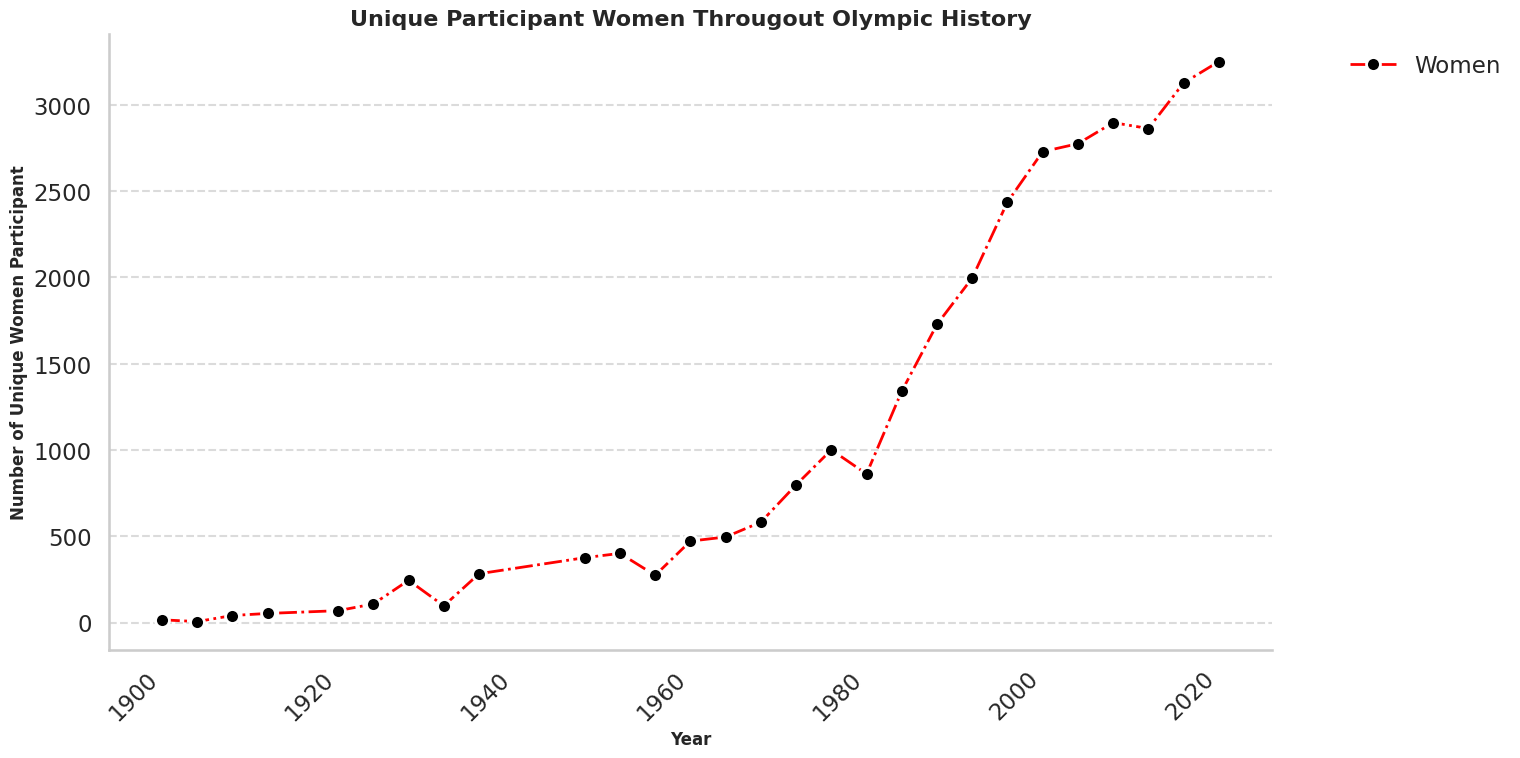

In [14]:
#Visualization
plt.figure(figsize=(15,8))
sns.set_theme(style="whitegrid",context="talk")
plt.title("Unique Participant Women Througout Olympic History",fontsize=16,fontweight="bold")

sns.lineplot(
          x=unique_W_par['year'],
          y=unique_W_par['name'],
          marker='o',
          markersize=10,
          markeredgecolor='white',
          markerfacecolor='black',
          markeredgewidth=2,
          color='red',
          linestyle='-.',
          linewidth=2,
          label='Women'
        )

plt.xlabel("Year",fontsize=12,fontweight="bold")
plt.ylabel("Number of Unique Women Participant",fontsize=12,fontweight="bold")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)

plt.xticks(rotation=45,ha="right")
sns.despine()

plt.show()


In [15]:
#The dips in graphs shows the women participant in winter olympics
#by this Graph we can see that the Women Participants increase masively in b/w 1980 to 2000
#the same pataren might not be shown in different country specific Women participant
#as in different country the timeline of women fighting for there right changes
#we will be looking at diffent country ex-USA , RUS , CHN ,IND and etc later on

#### Comparison of Participant

In [16]:
pm_t_d=t_d[t_d['event'].str.contains('Men',na=False) & (t_d['type'] == 'Summer')]

u_pm_d=pm_t_d.drop_duplicates(subset=['athlete_id'])

unique_M_par=u_pm_d.groupby(['year'])['name'].count().reset_index()

##### Visuals

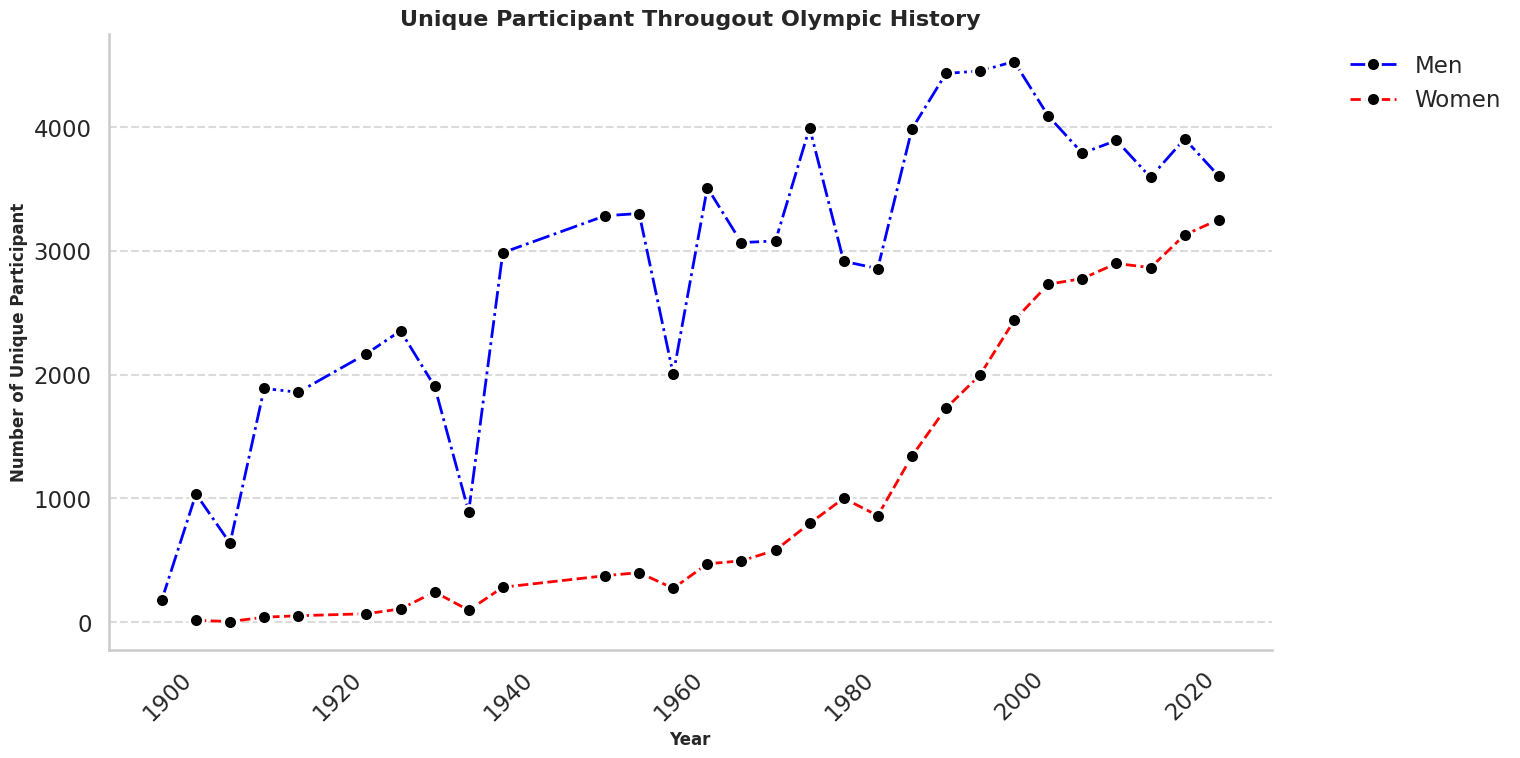

In [17]:
from re import L
#Visualization
plt.figure(figsize=(15,8))
sns.set_theme(style="whitegrid",context="talk")
plt.title("Unique Participant Througout Olympic History",fontsize=16,fontweight="bold")

#For Men

sns.lineplot(
              x=unique_M_par['year'],
              y=unique_M_par['name'],
              marker='o',
              markersize=10,
              markeredgecolor='white',
              markerfacecolor='black',
              markeredgewidth=2,
              color='blue',
              linestyle='-.',
              linewidth=2,
              label='Men'
            )

#For Women

sns.lineplot(
              x=unique_W_par['year'],
              y=unique_W_par['name'],
              marker='o',
              markersize=10,
              markeredgecolor='white',
              markerfacecolor='black',
              markeredgewidth=2,
              color='red',
              linestyle='--',
              linewidth=2,
              label='Women'
            )



plt.xlabel("Year",fontsize=12,fontweight="bold")
plt.ylabel("Number of Unique Participant",fontsize=12,fontweight="bold")

plt.xticks(rotation=45,ha="right")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

sns.despine()

plt.show()

## Physical Atribute Analysis

In [18]:
cp_t_d=t_d.dropna(subset=['height_cm','weight_kg'])
ucp_t_d=cp_t_d.drop_duplicates(subset=['athlete_id'])

#For Men
mucp_t_d=ucp_t_d[ucp_t_d['event'].str.contains('Men',na=False)]
gmucp_t_d=mucp_t_d.groupby(['discipline']).agg({'height_cm':'mean','weight_kg':'mean'}).reset_index()

# sport='Swimming|Gymnastics|Basketball|Soccer|Football|Ice Hockey|Skiing|Boxing|Athletics|Diving|Table|Cycling|Badminton|Rowing'
# sp_gmucp_t_d=gmucp_t_d[gmucp_t_d['discipline'].str.contains(sport,case=False,na=False)]
sp_gmucp_t_d=gmucp_t_d[gmucp_t_d['discipline'].isin(['Alpine Skiing (Skiing)','Artistic Gymnastics (Gymnastics)','Basketball (Basketball)',
                                                     'Football (Football)','Ice Hockey (Ice Hockey)','Swimming (Aquatics)','Table Tennis',
                                                     'Cycling Road (Cycling)','Badminton','Rowing'])]

#For Women
wucp_t_d=ucp_t_d[ucp_t_d['event'].str.contains('Women',na=False)]
gwucp_t_d=wucp_t_d.groupby(['discipline']).agg({'height_cm':'mean','weight_kg':'mean'}).reset_index()

sp_gwucp_t_d=gwucp_t_d[gwucp_t_d['discipline'].isin(['Alpine Skiing (Skiing)','Artistic Gymnastics (Gymnastics)','Basketball (Basketball)',
                                                     'Football (Football)','Ice Hockey (Ice Hockey)','Swimming (Aquatics)','Table Tennis',
                                                     'Cycling Road (Cycling)','Badminton','Rowing'])]

sp_gwucp_t_d

,discipline,height_cm,weight_kg
1,Alpine Skiing (Skiing),166.837689,61.888583
3,Artistic Gymnastics (Gymnastics),155.831272,47.294170
6,Badminton,168.020134,61.127517
7,Basketball (Basketball),182.084081,73.313901
18,Cycling Road (Cycling),167.590361,57.292169
23,Football (Football),167.409589,60.779452
28,Ice Hockey (Ice Hockey),167.590909,64.610390
35,Rowing,176.246844,69.542777
47,Swimming (Aquatics),170.538571,60.737857
48,Table Tennis,164.965079,57.787302


##### Visuals

### **Key Insights: Physical Trends Across Disciplines**

* **Height-Weight Correlation:** There is a highly consistent pattern between average height and weight across almost all disciplines. As height increases, weight follows a similar trajectory.
* **The Ice Hockey Outlier:** Ice Hockey stands out as an exception where the weight-to-height ratio deviates slightly compared to other sports.
* **Gender Consistency:** The "Gender Gap" (difference between male and female averages) remains remarkably stable across all analyzed sports. Whether in Gymnastics or Basketball, the margin between the two groups stays relatively the same.
* **Visualization Note:** To improve readability, using a `linestyle='-.'` helps distinguish the trend lines when they overlap closely.

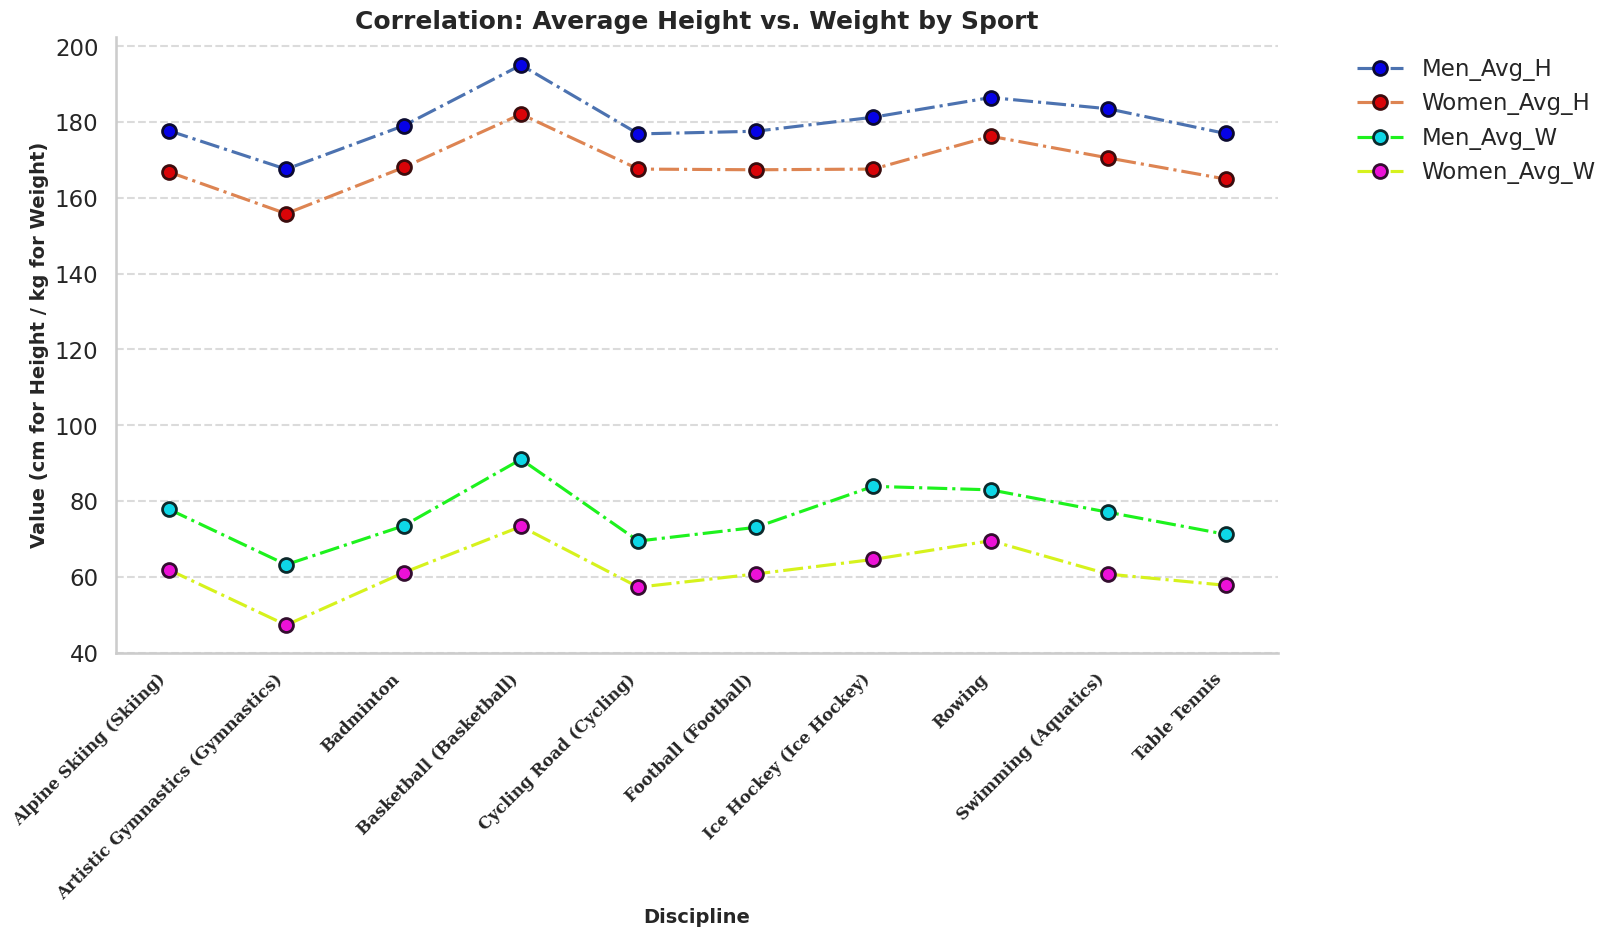

In [19]:

plt.figure(figsize=(15,8))

sns.set_theme(style="whitegrid",context="talk")
plt.title("Correlation: Average Height vs. Weight by Sport",fontsize=18,fontweight="bold")

#Men Avg Height
sns.lineplot(
              x=sp_gmucp_t_d['discipline'],
              y=sp_gmucp_t_d['height_cm'],
              marker='o',
              markersize=10,
              markeredgecolor='#0b0a30',
              markerfacecolor='#0602e6',
              markeredgewidth=2,
              linestyle='-.',
              label='Men_Avg_H' )

#Women Avg Height
sns.lineplot(
              x=sp_gwucp_t_d['discipline'],
              y=sp_gwucp_t_d['height_cm'],
              marker='o',
              markersize=10,
              markeredgecolor='#3b0c0d',
              markerfacecolor='#d90408',
              markeredgewidth=2,
              linestyle='-.',
              label='Women_Avg_H')
#Men Avg Weight
sns.lineplot(
              x=sp_gmucp_t_d['discipline'],
              y=sp_gmucp_t_d['weight_kg'],
              marker='o',
              markersize=10,
              markeredgecolor='#0c292b',
              markerfacecolor='#0ed7e6',
              markeredgewidth=2,
              linestyle='-.',
              color='#1df21d',
              label='Men_Avg_W')
#Women Avg Weight
sns.lineplot(
              x=sp_gwucp_t_d['discipline'],
              y=sp_gwucp_t_d['weight_kg'],
              marker='o',
              markersize=10,
              markeredgecolor='#330d2f',
              markerfacecolor='#ed11d7',
              markeredgewidth=2,
              linestyle='-.',
              color='#d6f21d',
              label='Women_Avg_W')

plt.xlabel("Discipline",fontsize=14,fontweight="bold")
plt.ylabel("Value (cm for Height / kg for Weight)",fontsize=14,fontweight="bold")

plt.xticks(rotation=45,ha="right",fontsize=12,
           fontweight='bold',
           fontfamily='serif')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)

sns.despine()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

plt.show()

## Age Analysis

#### Age Distribution

In [20]:
ct_d=t_d.dropna(subset=['born_date','year']).copy()

time_ct_d=pd.to_datetime(ct_d['born_date'])

ct_d['age']=ct_d['year']-time_ct_d.dt.year

age_t_d=ct_d.drop_duplicates(subset=['athlete_id'])

agec_t_d=age_t_d[['name','age']].copy()
agec_t_d['gender'] = 'Other'
agec_t_d.loc[age_t_d['event'].str.contains('Men', na=False), 'gender'] = 'Men'
agec_t_d.loc[age_t_d['event'].str.contains('Women', na=False), 'gender'] = 'Women'
agec_t_d.head(5)

,name,age,gender
0,Jean-François Blanchy,26.0,Men
5,Arnaud Boetsch,27.0,Men
7,Jean Borotra,26.0,Men
10,Jacques Brugnon,25.0,Men
13,Albert Canet,34.0,Men


##### Visual

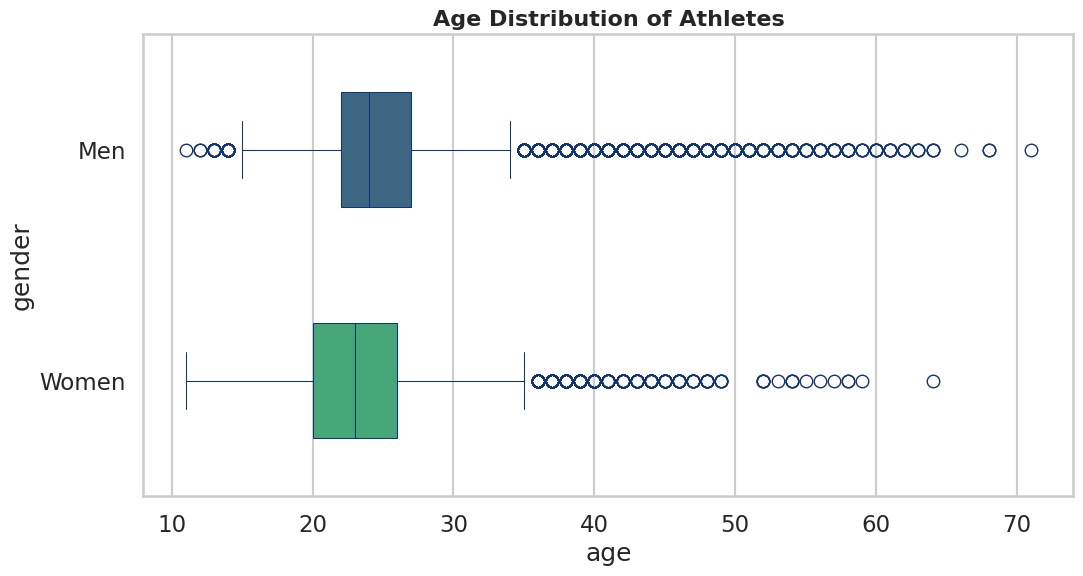

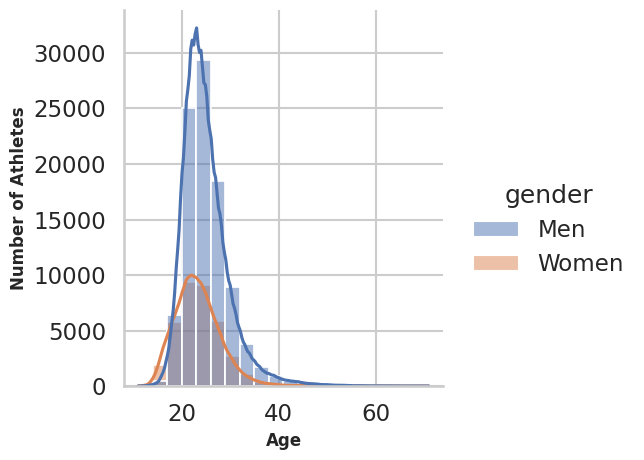

In [21]:
from pandas.core.indexes import multi

agec_t_d = agec_t_d[agec_t_d['gender'].isin(['Men', 'Women'])]

plt.figure(figsize=(12,6))

# sns.set_theme(style="whitegrid",context="talk")
plt.title("Age Distribution of Athletes",fontsize=16,fontweight="bold")

sns.boxplot(
             x=agec_t_d['age'],
             y=agec_t_d['gender'],
             hue=agec_t_d['gender'],
             legend=False,
             palette="viridis",
             color=".8",
             linecolor="#137",
             linewidth=.75,
             width=0.5
           )
sns.displot(
             age_t_d,
             x=agec_t_d['age'],
             hue=agec_t_d['gender'],
             bins=20,
             fill=True,
             kde=True
           )


plt.xlabel("Age",fontsize=12,fontweight="bold")
plt.ylabel("Number of Athletes",fontsize=12,fontweight="bold")

sns.despine()
plt.show()

#### Average Age across Year

In [22]:
avr_age_t_d=t_d.dropna(subset=['medal','born_date','year','event']).copy()
#for Medalist
avr_age_t_d=avr_age_t_d.drop_duplicates(subset=['athlete_id'])
# Removing winter olympic
avr_age_t_d=avr_age_t_d[avr_age_t_d['type'].isin(['Summer'])]

born=pd.to_datetime(avr_age_t_d['born_date'])
avr_age_t_d['age']=avr_age_t_d['year']-born.dt.year
avr_age_t_d['gender']=avr_age_t_d['event'].apply(lambda x: 'Men' if 'Men' in x else ('Women' if 'Women' in x else 'Other'))
avr_age_t_d=avr_age_t_d.groupby(['gender','year'])['age'].mean().reset_index()

##### Visual

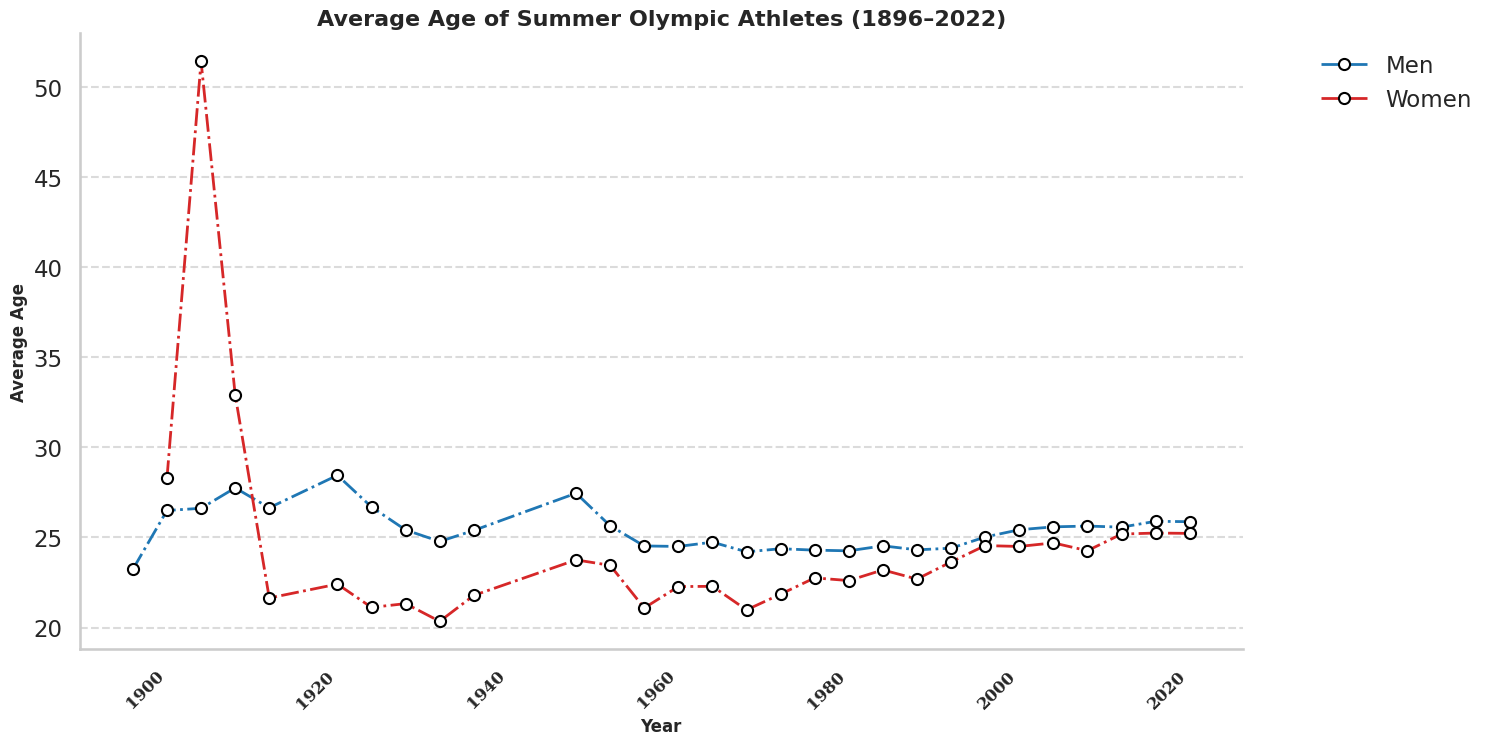

In [23]:
age_trend_filtered = avr_age_t_d[avr_age_t_d['gender'].isin(['Men', 'Women'])]

plt.figure(figsize=(15,8))

sns.set_theme(style="whitegrid",context="talk")
plt.title("Average Age of Summer Olympic Athletes (1896–2022)",fontsize=16,fontweight="bold")

# For Medalist
sns.lineplot(
              data=age_trend_filtered,
              x='year',
              y='age',
              hue='gender',
              marker='o',
              markersize=8,
              markerfacecolor='white',
              markeredgecolor='black',
              markeredgewidth=1.5,
              linestyle='-.',
              linewidth=2,
              palette=['#1f77b4', '#d62728']
           )

plt.xlabel("Year" , fontsize=12 , fontweight="bold")
plt.ylabel("Average Age" , fontsize=12  ,fontweight="bold")

plt.xticks(rotation=45,ha="right",fontsize=12,
           fontweight='bold',
           fontfamily='serif')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)

sns.despine()

plt.show()


## Home Advantage

In [24]:
host_map = {
    1896: 'GRE', 1900: 'FRA', 1904: 'USA', 1908: 'GBR', 1912: 'SWE',
    1920: 'BEL', 1924: 'FRA', 1928: 'NED', 1932: 'USA', 1936: 'GER',
    1948: 'GBR', 1952: 'FIN', 1956: 'AUS', 1960: 'ITA', 1964: 'JPN',
    1968: 'MEX', 1972: 'FRG', 1976: 'CAN', 1980: 'URS', 1984: 'USA',
    1988: 'KOR', 1992: 'ESP', 1996: 'USA', 2000: 'AUS', 2004: 'GRE',
    2008: 'CHN', 2012: 'GBR', 2016: 'BRA', 2020: 'JPN'
}
t_d['host_noc'] = t_d['year'].map(host_map)

In [25]:
r_dict={
    'URS':'RUS','FRG':'GER','GDR':'GER'
}
t_d['host_noc']=t_d['year'].map(host_map)

t_d['noc']=t_d['noc'].replace(r_dict)
t_d['host_noc']=t_d['host_noc'].replace(r_dict)



fil_t_d=t_d.dropna(subset=['medal','noc','host_noc','year'])
fil_t_d=fil_t_d.drop_duplicates(subset=['athlete_id'])
fil_t_d=fil_t_d[fil_t_d['type'].isin(['Summer']) & fil_t_d['medal'].isin(['Gold'])]

group_t_d=fil_t_d.groupby(['year','noc','medal'])['name'].count().reset_index()

t_d['host_noc']=t_d['year'].map(host_map)

t_d['noc']=t_d['noc'].replace(r_dict)
t_d['host_noc']=t_d['host_noc'].replace(r_dict)

top_country=group_t_d[group_t_d['noc'].isin(['USA','RUS','GER','FRA','CHN'])].copy()

top_country['host_noc']=top_country['year'].map(host_map)
top_country['noc']=top_country['noc'].replace(r_dict)

top_country['host_noc']=top_country['host_noc'].replace(r_dict)
top_country.head()

host_only=top_country[top_country['noc']==top_country['host_noc']]

host_only.head()

,year,noc,medal,name,host_noc
12,1900.0,FRA,Gold,48,FRA
26,1904.0,USA,Gold,82,USA
74,1924.0,FRA,Gold,23,FRA
129,1932.0,USA,Gold,58,USA
138,1936.0,GER,Gold,74,GER


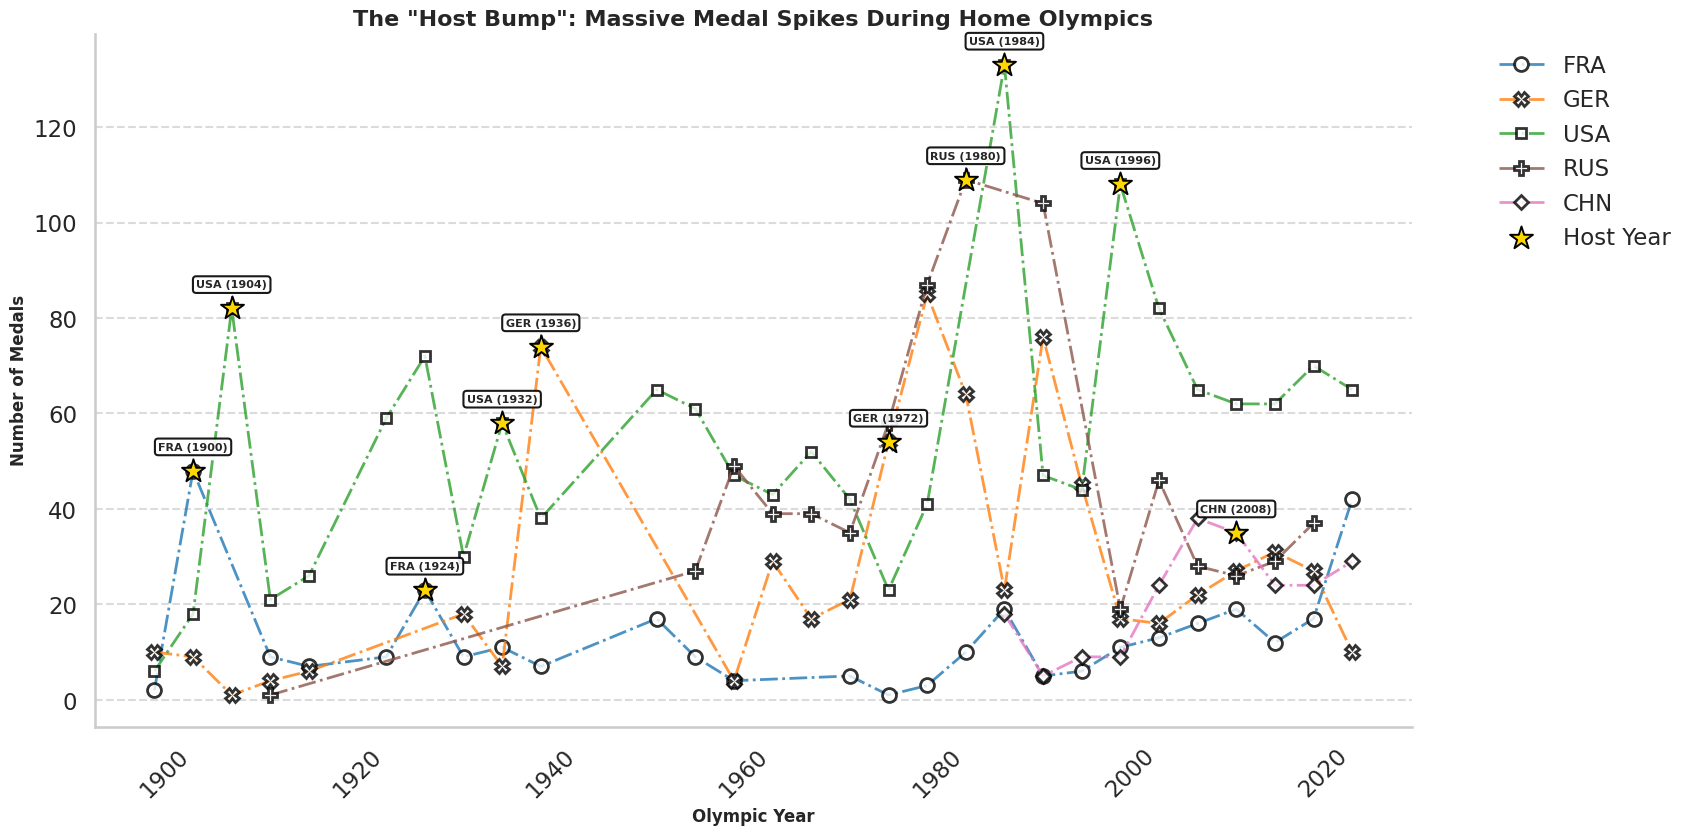

In [26]:
plt.figure(figsize=(17,9))
sns.set_theme(style="whitegrid",context="talk")

# Top country Gold medals
sns.lineplot(
              data=top_country,
              x='year',
              y='name',
              hue='noc',
              style='noc',
              markers=True,
              dashes=False,
              markersize=10,
              markerfacecolor='white',
              markeredgecolor='black',
              markeredgewidth=2,
              linestyle='-.',
              alpha=0.8,
              linewidth=2,
              palette=['#1f77b4','#ff7f0e','#2ca02c','#8c564b','#e377c2']
            )
# Host Country Marker
sns.scatterplot(
                data=host_only,
                x='year',
                y='name',
                marker='*',
                s=300,
                color='gold',
                edgecolor='black',
                label='Host Year',
                zorder=5
                )



plt.title('The "Host Bump": Massive Medal Spikes During Home Olympics',fontsize=16,fontweight="bold")
plt.xlabel("Olympic Year",fontsize=12,fontweight="bold")
plt.ylabel("Number of Medals",fontsize=12,fontweight="bold")

plt.xticks(rotation=45,ha="right")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', visible=False)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)

label_style=bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.9)
for i,row in host_only.iterrows():
  if row['name'] > 20:
        plt.annotate(
            f"{row['noc']} ({int(row['year'])})",
            xy=(row['year'], row['name']),
            xytext=(0, 15),
            textcoords='offset points',
            ha='center',
            fontsize=8,
            fontweight='bold',
            bbox=label_style,
            arrowprops=dict(arrowstyle='-', color='black', lw=0.5),

        )

sns.despine()

plt.show()